# 多元线性回归-特征缩放

这一节重点说明：当不同特征的数值大小差异很大时，模型训练会更难。

## 1. 数据样例

下面展示 `data/data_house.csv` 的前三行数据：

| $x_1$ 面积 | $x_2$ 卧室数 | $x_3$ 楼层 | $x_4$ 房龄 | $y$ 房价 |
| --- | --- | --- | --- | --- |
| 155.1 | 3 | 18 | 15 | 354.62 |
| 172.6 | 4 | 6 | 27 | 361.22 |
| 56.9 | 1 | 33 | 1 | 196.82 |
| ... | ... | ... | ... | ... |

## 2. 特征过大会带来什么问题

先分别观察面积、卧室数、楼层、房龄对房价的影响。四幅图的横轴尺度明显不同：面积通常是几十到几百，而卧室数通常只有 1 到 5。

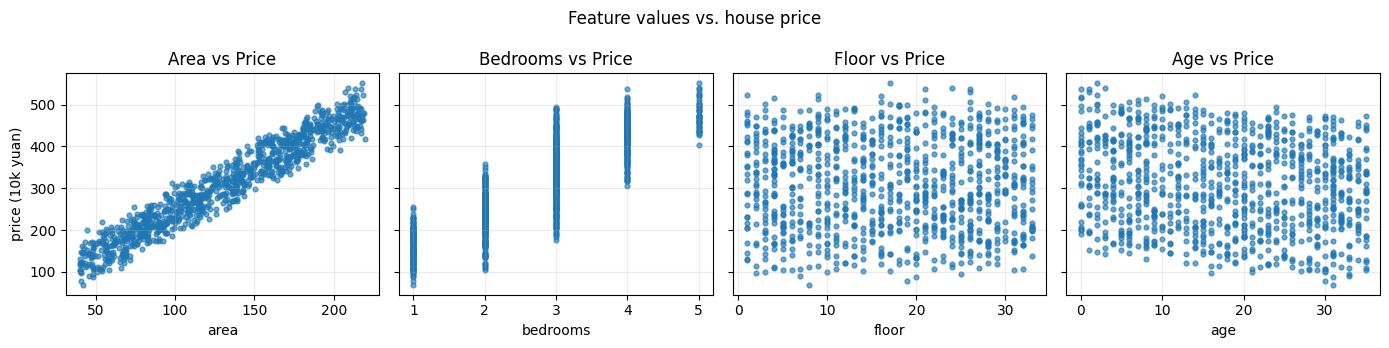

In [49]:
import numpy as np
import matplotlib.pyplot as plt


data = np.genfromtxt("data/data_house.csv", delimiter=",", skip_header=1)

feature_names = ["x_1", "x_2", "x_3", "x_4"]
feature_labels = ["area", "bedrooms", "floor", "age"]
feature_titles = ["Area vs Price", "Bedrooms vs Price", "Floor vs Price", "Age vs Price"]

X = data[:, :4]
y = data[:, 4]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), sharey=True)

for i, ax in enumerate(axes):
    ax.scatter(X[:, i], y, s=12, alpha=0.65)
    ax.set_title(feature_titles[i])
    ax.set_xlabel(feature_labels[i])
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("price (10k yuan)")
fig.suptitle("Feature values vs. house price")
plt.tight_layout()
plt.show()

再看每个特征的取值范围，面积这一列明显比卧室数大很多。

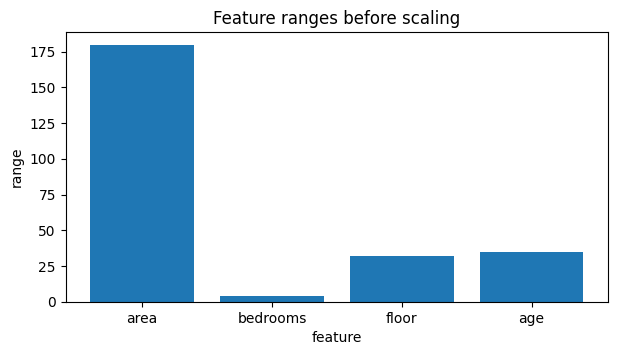

area: 179.6
bedrooms: 4.0
floor: 32.0
age: 35.0


In [50]:
ranges = np.ptp(X, axis=0)

plt.figure(figsize=(7, 3.5))
plt.bar(feature_labels, ranges)
plt.xlabel("feature")
plt.ylabel("range")
plt.title("Feature ranges before scaling")
plt.show()

for name, value_range in zip(feature_labels, ranges):
    print(f"{name}: {value_range:.1f}")

| 影响 |
| --- |
| 1.模型容易被大数字的特征带着跑 | 
| 2.学习时一会儿改太多，一会儿改不够 |
| 3.训练速度可能变慢 |
| 4.学习率稍微大一点，结果就可能乱跳 |

![特征缩放示意图](image/03_scaling.png)

## 3. 特征缩放效果

下面只取 CSV 前三条数据做演示，观察同一批样本在缩放前后的数值变化。

In [51]:
def zscore_normalize_features(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_scaled = (X - mu) / sigma
    return X_scaled, mu, sigma


X_demo = X[:3]
X_demo_scaled, X_demo_mu, X_demo_sigma = zscore_normalize_features(X_demo)

print("缩放前前三条数据：")
print("编号\t面积\t卧室数\t楼层\t房龄")
for i, row in enumerate(X_demo, start=1):
    print(f"{i}\t{row[0]:.1f}\t{row[1]:.0f}\t{row[2]:.0f}\t{row[3]:.0f}")

# print("\n前三条数据的均值和标准差：")
# print(f"mu: {X_demo_mu}")
# print(f"sigma: {X_demo_sigma}")

print("\n缩放后前三条数据：")
print("编号\t面积\t卧室数\t楼层\t房龄")
for i, row in enumerate(X_demo_scaled, start=1):
    print(f"{i}\t{row[0]:.3f}\t{row[1]:.3f}\t{row[2]:.3f}\t{row[3]:.3f}")

# 第 4 节训练效果对比仍然使用完整数据集的缩放结果。
X_scaled, X_mu, X_sigma = zscore_normalize_features(X)

缩放前前三条数据：
编号	面积	卧室数	楼层	房龄
1	155.1	3	18	15
2	172.6	4	6	27
3	56.9	1	33	1

缩放后前三条数据：
编号	面积	卧室数	楼层	房龄
1	0.528	0.267	-0.091	0.063
2	0.872	1.069	-1.177	1.192
3	-1.400	-1.336	1.268	-1.255


## 4. 特征缩放算法

常用方法是 z-score 标准化：每个特征先减去自己的均值，再除以自己的标准差。

特征均值：

$$
\mu_j = \frac{1}{m}\sum_{i=1}^{m}x_j^{(i)}
$$

特征标准差：

$$
\sigma_j = \sqrt{\frac{1}{m}\sum_{i=1}^{m}(x_j^{(i)}-\mu_j)^2}
$$

z-score 标准化：

$$
x_{j,scaled}^{(i)} = \frac{x_j^{(i)} - \mu_j}{\sigma_j}
$$

缩放前后，预测函数、代价函数和梯度下降的结构不变，变化的是输入特征从 $x_j$ 变成 $x_{j,scaled}$：

| 对比项 | 缩放前 | 缩放后 |
| --- | --- | --- |
| 输入特征 | $x_j$ | $x_{j,scaled}=\frac{x_j-\mu_j}{\sigma_j}$ |
| 预测函数 | $f_{\vec{w},b}(\vec{x})=\vec{w}\cdot\vec{x}+b$ | $f_{\vec{w},b}(\vec{x}_{scaled})=\vec{w}\cdot\vec{x}_{scaled}+b$ |
| 代价函数 | $J(\vec{w},b)=\frac{1}{2m}\sum_{i=1}^{m}(f_{\vec{w},b}(\vec{x}^{(i)})-y^{(i)})^2$ | $J(\vec{w},b)=\frac{1}{2m}\sum_{i=1}^{m}(f_{\vec{w},b}(\vec{x}_{scaled}^{(i)})-y^{(i)})^2$ |
| 权重梯度 | $\frac{\partial J}{\partial w_j}=\frac{1}{m}\sum_{i=1}^{m}(f_{\vec{w},b}(\vec{x}^{(i)})-y^{(i)})x_j^{(i)}$ | $\frac{\partial J}{\partial w_j}=\frac{1}{m}\sum_{i=1}^{m}(f_{\vec{w},b}(\vec{x}_{scaled}^{(i)})-y^{(i)})x_{j,scaled}^{(i)}$ |
| 偏置梯度 | $\frac{\partial J}{\partial b}=\frac{1}{m}\sum_{i=1}^{m}(f_{\vec{w},b}(\vec{x}^{(i)})-y^{(i)})$ | $\frac{\partial J}{\partial b}=\frac{1}{m}\sum_{i=1}^{m}(f_{\vec{w},b}(\vec{x}_{scaled}^{(i)})-y^{(i)})$ |
| 参数更新 | $w_j := w_j - \alpha\frac{\partial J}{\partial w_j}$，$b := b - \alpha\frac{\partial J}{\partial b}$ | 公式不变，但特征尺度接近后，梯度更新通常更均衡 |

In [54]:
def compute_cost(X, y, w, b):
    m = len(y)
    error = X @ w + b - y
    return np.sum(error ** 2) / (2 * m)


def gradient_descent(X, y, alpha, num_iters):
    m, n = X.shape
    w = np.zeros(n)
    b = 0.0
    cost_history = []

    for _ in range(num_iters):
        error = X @ w + b - y
        dj_dw = X.T @ error / m
        dj_db = np.sum(error) / m

        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        cost_history.append(compute_cost(X, y, w, b))

    return w, b, cost_history


num_iters = 100
w_raw, b_raw, cost_raw = gradient_descent(X, y, alpha=0.00001, num_iters=num_iters)
w_scaled, b_scaled, cost_scaled = gradient_descent(X_scaled, y, alpha=0.1, num_iters=num_iters)

print("训练设置：")
print("未缩放数据学习率 alpha = 0.00001")
print("已缩放数据学习率 alpha = 0.1")
print()
print(f"未缩放最终代价: {cost_raw[-1]:.2f}")
print(f"已缩放最终代价: {cost_scaled[-1]:.2f}")

训练设置：
未缩放数据学习率 alpha = 0.00001
已缩放数据学习率 alpha = 0.1

未缩放最终代价: 465.65
已缩放最终代价: 57.85


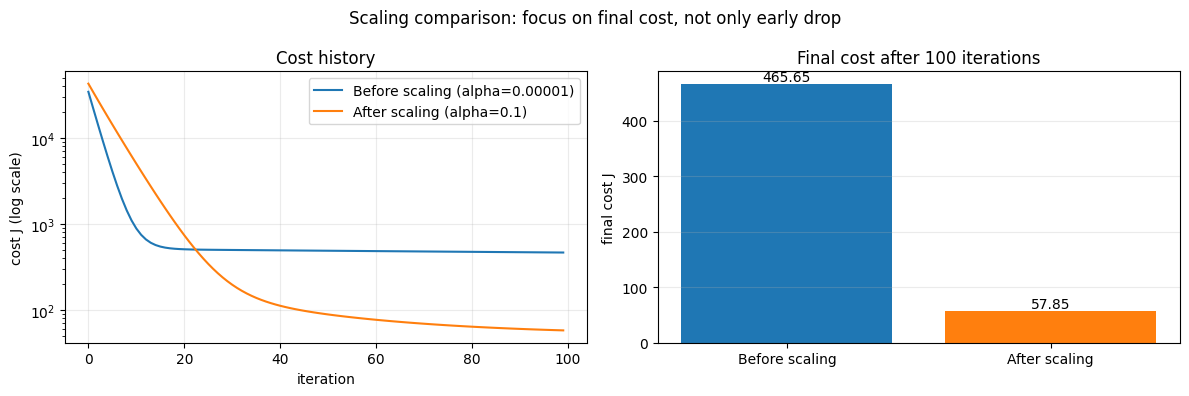

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(cost_raw, label="Before scaling (alpha=0.00001)")
axes[0].plot(cost_scaled, label="After scaling (alpha=0.1)")
axes[0].set_yscale("log")
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("cost J (log scale)")
axes[0].set_title("Cost history")
axes[0].legend()
axes[0].grid(True, alpha=0.25)

final_costs = [cost_raw[-1], cost_scaled[-1]]
bars = axes[1].bar(["Before scaling", "After scaling"], final_costs, color=["tab:blue", "tab:orange"])
axes[1].set_ylabel("final cost J")
axes[1].set_title("Final cost after 100 iterations")
axes[1].bar_label(bars, fmt="%.2f")
axes[1].grid(axis="y", alpha=0.25)

fig.suptitle("Scaling comparison: focus on final cost, not only early drop")
plt.tight_layout()
plt.show()

## 5. 小结

特征缩放的核心作用是让不同特征的尺度接近，从而让模型训练更稳定、更容易收敛。